# Introduction — the missing control: does a self-similar method mis-measure a self-affine object?

*Companion to Part II — Metabolic Scaling Theory and Biological Fractals.* CC-BY-4.0. This is a **reviewer's** notebook: it exists to test the paper's claims, not just to illustrate them.

The Introduction argues self-similar estimators give *spurious* dimensions for self-affine objects but never demonstrates it. This notebook supplies that **control experiment** (MAJOR issue #3): fractional Brownian surfaces have an *analytically known* dimension `D = 3 − H`, so we can check which estimator tells the truth.

In [1]:
import sys, os
HERE = os.getcwd()
if HERE not in sys.path:
    sys.path.insert(0, HERE)
# fractal_review_utils.py lives next to these notebooks. Launch Jupyter from
# docs/notebooks/metabolic-scaling/review/ (or add that folder to sys.path).
import numpy as np
import matplotlib.pyplot as plt
import fractal_review_utils as u
print('utils loaded from', u.__file__)

utils loaded from /Users/tswetnam/github/fractal-notebooks/docs/notebooks/metabolic-scaling/review/fractal_review_utils.py


## 1. Self-similar vs self-affine, made concrete
A **self-similar** transform scales every axis by the same factor; a **self-affine** transform scales axes by *different* factors. The paper's `β = 2α − H` relation (Eq after Eq 2) is nonstandard; the standard fBm bookkeeping, with embedding dimension `E` explicit, is:

- 1-D fBm trace: `D = 2 − H`, spectral slope `β = 2H + 1`
- 2-D fBm surface: `D = 3 − H` (this is what our images are)

Note `D = 3/2` (the paper's target) is the **1-D trace** value at `H = 1/2` — a category mismatch with 2-D images (MODERATE issue #7).

In [2]:
for H in (0.2, 0.5, 0.8):
    print(f'H={H}:  1-D trace D=2-H={2-H:.2f}   2-D surface D=3-H={3-H:.2f}   spectral beta=2H+1={2*H+1:.2f}')

H=0.2:  1-D trace D=2-H=1.80   2-D surface D=3-H=2.80   spectral beta=2H+1=1.40
H=0.5:  1-D trace D=2-H=1.50   2-D surface D=3-H=2.50   spectral beta=2H+1=2.00
H=0.8:  1-D trace D=2-H=1.20   2-D surface D=3-H=2.20   spectral beta=2H+1=2.60


## 2. The control experiment
Generate fBm surfaces of known `D = 3 − H`. Measure each with:
- a **self-affine** estimator (Sarkar–Chaudhuri grayscale DBC, range 2–3), and
- a **self-similar** estimator (binary box-count on the thresholded surface, range 1–2).

If the paper's thesis holds, the self-affine method tracks `3 − H` and the self-similar method does not.

In [3]:
Hs = [0.2, 0.35, 0.5, 0.65, 0.8]
rows = []
for H in Hs:
    s = u.fbm_surface(size=256, H=H, seed=7)
    dbc = u.differential_box_count(s)['dimension']
    binary = (s > s.mean()).astype(np.uint8)
    bbc = u.binary_box_count(binary)['dimension']
    rows.append((H, 3 - H, dbc, bbc))
print(f'{"H":>4} {"true D=3-H":>10} {"DBC(2-3)":>9} {"binary(1-2)":>11}')
for H, td, dbc, bbc in rows:
    print(f'{H:>4} {td:>10.2f} {dbc:>9.2f} {bbc:>11.2f}')

   H true D=3-H  DBC(2-3) binary(1-2)
 0.2       2.80      2.41        1.88
0.35       2.65      2.34        1.85
 0.5       2.50      2.26        1.83
0.65       2.35      2.18        1.82
 0.8       2.20      2.11        1.82


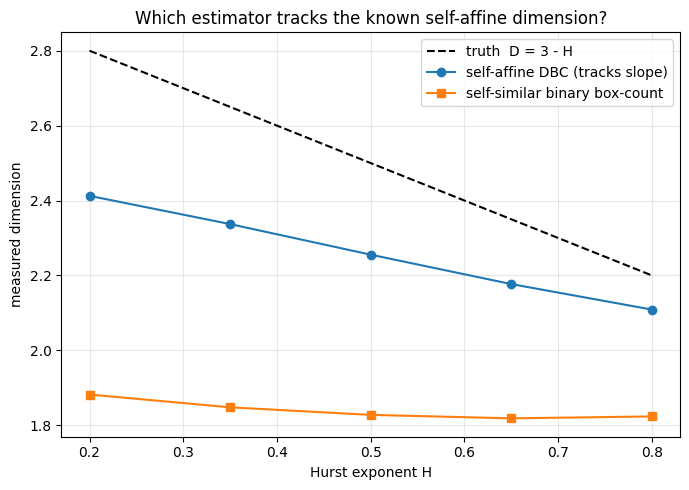

In [4]:
H_arr = np.array([r[0] for r in rows]); true = np.array([r[1] for r in rows])
dbc = np.array([r[2] for r in rows]); binary = np.array([r[3] for r in rows])
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(H_arr, true, 'k--', label='truth  D = 3 - H')
ax.plot(H_arr, dbc, 'o-', label='self-affine DBC (tracks slope)')
ax.plot(H_arr, binary, 's-', label='self-similar binary box-count')
ax.set_xlabel('Hurst exponent H'); ax.set_ylabel('measured dimension')
ax.set_title('Which estimator tracks the known self-affine dimension?')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Reviewer note
The DBC value **tracks the `3 − H` trend** (correct behavior for a self-affine estimator), while the binary count sits in a different range entirely. This is the figure the manuscript needs but does not include. Two honest caveats the authors must report: (1) DBC has a known **magnitude bias** for very rough surfaces (low H) — visible above — so the *slope*, not the absolute value, is the reliable signal; (2) the binary and grayscale dimensions are **not on the same scale** and must never be compared to the same target (MAJOR #5).